<a href="https://colab.research.google.com/github/kowshika-santhosh-2111data/Driver_Drowsiness_Detection/blob/main/Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random

import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas"
classes = ["Open", "Closed", "yawn", "no_yawn"]

In [ ]:
print(os.listdir("/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas"))

['yawn', 'Open', 'no_yawn', 'Closed']


In [ ]:
print(dataset_path)

/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas


In [ ]:
for cls in classes:
    folder = os.path.join(dataset_path, cls)
    print(folder, os.path.exists(folder))

/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas/Open True
/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas/Closed True
/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas/yawn True
/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas/no_yawn True


In [ ]:
image_counts = {}

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    print(folder, os.path.exists(folder))
    image_counts[cls] = len(os.listdir(folder))

df = pd.DataFrame(image_counts.items(),
      columns=["Class", "Number of Images"])
df

/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas/Open True
/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas/Closed True
/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas/yawn True
/content/drive/MyDrive/Driver_Drowsiness_Detection/Datas/no_yawn True


,Class,Number of Images
0,Open,726
1,Closed,726
2,yawn,723
3,no_yawn,725


In [ ]:
total_images = sum(image_counts.values())

print("Total Images :", total_images)

for cls, count in image_counts.items():
    print(f"{cls}: {count}")

Total Images : 2900
Open: 726
Closed: 726
yawn: 723
no_yawn: 725


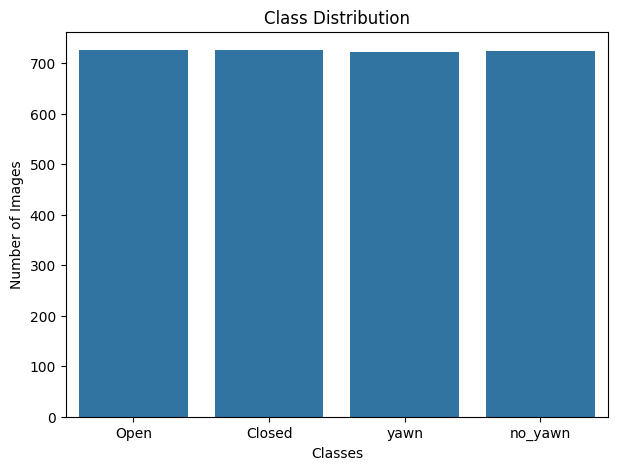

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(x=list(image_counts.keys()),
            y=list(image_counts.values()))

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
percentages = {}

for cls, count in image_counts.items():
    percentages[cls] = (count/total_images)*100

pd.DataFrame({
    "Class": percentages.keys(),
    "Percentage": percentages.values()
})

,Class,Percentage
0,Open,25.034483
1,Closed,25.034483
2,yawn,24.931034
3,no_yawn,25.000000


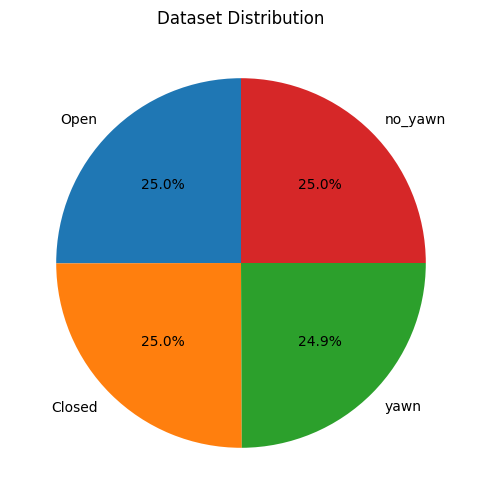

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    image_counts.values(),
    labels=image_counts.keys(),
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Dataset Distribution")
plt.show()

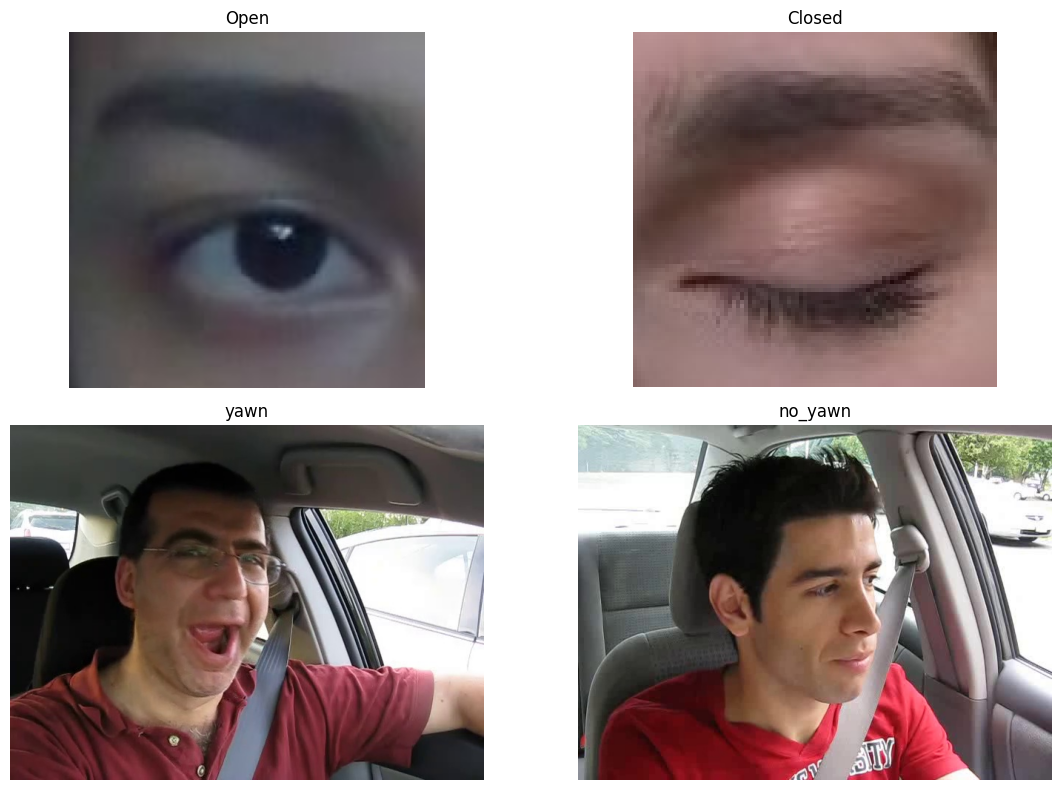

In [ ]:
plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    folder = os.path.join(dataset_path, cls)

    img_name = random.choice(os.listdir(folder))

    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
for cls in classes:

    folder = os.path.join(dataset_path, cls)

    img_name = random.choice(os.listdir(folder))

    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path)

    print(f"{cls} Image Shape: {img.shape}")

Open Image Shape: (300, 382, 3)
Closed Image Shape: (300, 314, 3)
yawn Image Shape: (480, 640, 3)
no_yawn Image Shape: (480, 640, 3)


In [ ]:
images = []
labels = []

for label, folder in enumerate(classes):

    path = os.path.join(dataset_path, folder)

    for file in os.listdir(path):
        img_path = os.path.join(path, file)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (224, 224))

        images.append(img)
        labels.append(label)

In [ ]:
x = np.array(images, dtype=np.float32)
y = np.array(labels)
x = x / 255.0

In [ ]:

np.save("/content/drive/MyDrive/Driver_Drowsiness_Detection/x.npy", x)
np.save("/content/drive/MyDrive/Driver_Drowsiness_Detection/y.npy", y)

print("Saved successfully!")

Saved successfully!


In [ ]:
from sklearn.model_selection import train_test_split
# CNN
x_train_cnn, x_test_cnn, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    brightness_range=[0.8,1.2],
    horizontal_flip=True
)

train_datagen.fit(x_train_cnn)